### Model Training

In [2]:
# Step 1: Load the dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('dataset/0.01percent_2classes.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Dataset loaded successfully!
Shape: (466657, 47)

First few rows:
   flow_duration  header_length protocol_type  duration  rate  srate  drate  \
0       0.000000             54           TCP     64.00    37     37    0.0   
1       0.000000             54           TCP     64.00    29     29    0.0   
2       0.000000             54           TCP     64.00     0      0    0.0   
3       0.048848             60           TCP     65.91     1      1    0.0   
4       0.555381         883353           UDP     64.00  2870   2870    0.0   

   fin_flag_number  syn_flag_number  rst_flag_number  ...       std  tot_size  \
0            False             True            False  ...  0.000000     54.00   
1             True            False             True  ...  0.000000     54.00   
2            False             True            False  ...  0.000000     54.00   
3            False             True            False  ...  2.532528     54.67   
4            False            False            False  

In [3]:
# Step 2: Separate features and target
# Target variable: 'benign' (True = benign/normal, False = attack)
# Convert boolean target to 0 and 1 (0 = attack, 1 = benign)

X = df.drop('benign', axis=1)  # All features except target
y = (~df['benign']).astype(int)  # Convert: False (attack) -> 1, True (benign) -> 0

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution (1 = attack, 0 = benign):")
print(y.value_counts())
print(f"\nTarget balance (%):")
print(y.value_counts(normalize=True) * 100)

Features shape: (466657, 46)
Target shape: (466657,)

Target distribution (1 = attack, 0 = benign):
benign
1    455673
0     10984
Name: count, dtype: int64

Target balance (%):
benign
1    97.646237
0     2.353763
Name: proportion, dtype: float64


In [4]:
# Step 3: Handle categorical variables
# protocol_type is the only categorical column, encode it

# Find categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Encode categorical variables using LabelEncoder
X_encoded = X.copy()
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    le_dict[col] = le
    print(f"\n{col} encoding:")
    for i, label in enumerate(le.classes_):
        print(f"  {label} -> {i}")

print(f"\nEncoded features shape: {X_encoded.shape}")
print(f"Encoded data types:\n{X_encoded.dtypes}")

Categorical columns: ['protocol_type']

protocol_type encoding:
  3PC -> 0
  ARGUS (deprecated) -> 1
  BBN-RCC-MON -> 2
  CBT -> 3
  CHAOS -> 4
  DCCP -> 5
  DCN-MEAS -> 6
  DDP -> 7
  EGP -> 8
  EMCON -> 9
  GGP -> 10
  GRE -> 11
  HMP -> 12
  HOPOPT -> 13
  ICMP -> 14
  IDPR -> 15
  IDPR-CMTP -> 16
  IDRP -> 17
  IGMP -> 18
  IGP -> 19
  IL -> 20
  IPv4 -> 21
  IPv6 -> 22
  IPv6-Frag -> 23
  IPv6-Route -> 24
  IRTP -> 25
  ISO-TP4 -> 26
  LEAF-1 -> 27
  LEAF-2 -> 28
  MERIT-INP -> 29
  MFE-NSP -> 30
  MUX -> 31
  NETBLT -> 32
  NVP-II -> 33
  PRM -> 34
  PUP -> 35
  RDP -> 36
  RSVP -> 37
  SDRP -> 38
  ST -> 39
  TCP -> 40
  TP++ -> 41
  TRUNK-1 -> 42
  TRUNK-2 -> 43
  UDP -> 44
  XNET -> 45
  XNS-IDP -> 46
  XTP -> 47

Encoded features shape: (466657, 46)
Encoded data types:
flow_duration      float64
header_length        int64
protocol_type        int64
duration           float64
rate                 int64
srate                int64
drate              float64
fin_flag_number      

/tmp/ipykernel_157036/2201484125.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


In [5]:
# Step 4: Train-test split
# Use stratified split to maintain class distribution in train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,           # 80% train, 20% test
    random_state=42,
    stratify=y               # Maintain class distribution
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: (373325, 46)
Test set size: (93332, 46)

Training set class distribution:
benign
1    364538
0      8787
Name: count, dtype: int64

Test set class distribution:
benign
1    91135
0     2197
Name: count, dtype: int64


In [6]:
# Step 5: Train Random Forest with class weighting
# class_weight='balanced' handles the imbalance by penalizing misclassification of minority class

print("Training Random Forest Classifier...")
print("Using class_weight='balanced' to handle class imbalance\n")

rf_model = RandomForestClassifier(
    n_estimators=100,              # Number of trees
    max_depth=15,                  # Maximum depth of trees
    min_samples_split=5,           # Minimum samples to split
    min_samples_leaf=2,            # Minimum samples at leaf
    class_weight='balanced',       # Handle imbalance automatically
    random_state=42,
    n_jobs=-1                      # Use all processors
)

# Train the model
rf_model.fit(X_train, y_train)

print("✓ Model training completed!")
print(f"\nModel parameters:")
print(f"  n_estimators: {rf_model.n_estimators}")
print(f"  max_depth: {rf_model.max_depth}")
print(f"  Number of features: {rf_model.n_features_in_}")

Training Random Forest Classifier...
Using class_weight='balanced' to handle class imbalance

✓ Model training completed!

Model parameters:
  n_estimators: 100
  max_depth: 15
  Number of features: 46


In [8]:
# Step 6: Make predictions on test set

# Predictions
y_pred = rf_model.predict(X_test)

# Probability predictions (for ROC-AUC)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Predictions generated!")
print(f"\nPredictions summary:")
print(f"  Attack (1): {(y_pred == 1).sum()}")
print(f"  Benign (0): {(y_pred == 0).sum()}")

Predictions generated!

Predictions summary:
  Attack (1): 90564
  Benign (0): 2768


In [9]:
# Step 7: Evaluate the model
# Use proper metrics for imbalanced data (not just accuracy)

print("=" * 60)
print("MODEL EVALUATION ON TEST SET")
print("=" * 60)

# Classification Report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print("(1 = Attack, 0 = Benign)")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Benign  Attack")
print(f"Actual Benign    {cm[0, 0]:6d}  {cm[0, 1]:6d}")
print(f"       Attack    {cm[1, 0]:6d}  {cm[1, 1]:6d}")

# Key metrics
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nKey Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}  (of predicted attacks, how many are correct)")
print(f"  Recall:    {recall:.4f}    (of actual attacks, how many we caught)")
print(f"  F1-Score:  {f1:.4f}")

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"  ROC-AUC:   {roc_auc:.4f}    (probability ranking quality)")
print("=" * 60)

MODEL EVALUATION ON TEST SET

Classification Report:
(1 = Attack, 0 = Benign)
------------------------------------------------------------
              precision    recall  f1-score   support

      Benign       0.79      1.00      0.88      2197
      Attack       1.00      0.99      1.00     91135

    accuracy                           0.99     93332
   macro avg       0.90      1.00      0.94     93332
weighted avg       0.99      0.99      0.99     93332


Confusion Matrix:
                 Predicted
                 Benign  Attack
Actual Benign      2189       8
       Attack       579   90556

Key Metrics:
  Accuracy:  0.9937
  Precision: 0.9999  (of predicted attacks, how many are correct)
  Recall:    0.9936    (of actual attacks, how many we caught)
  F1-Score:  0.9968
  ROC-AUC:   0.9993    (probability ranking quality)


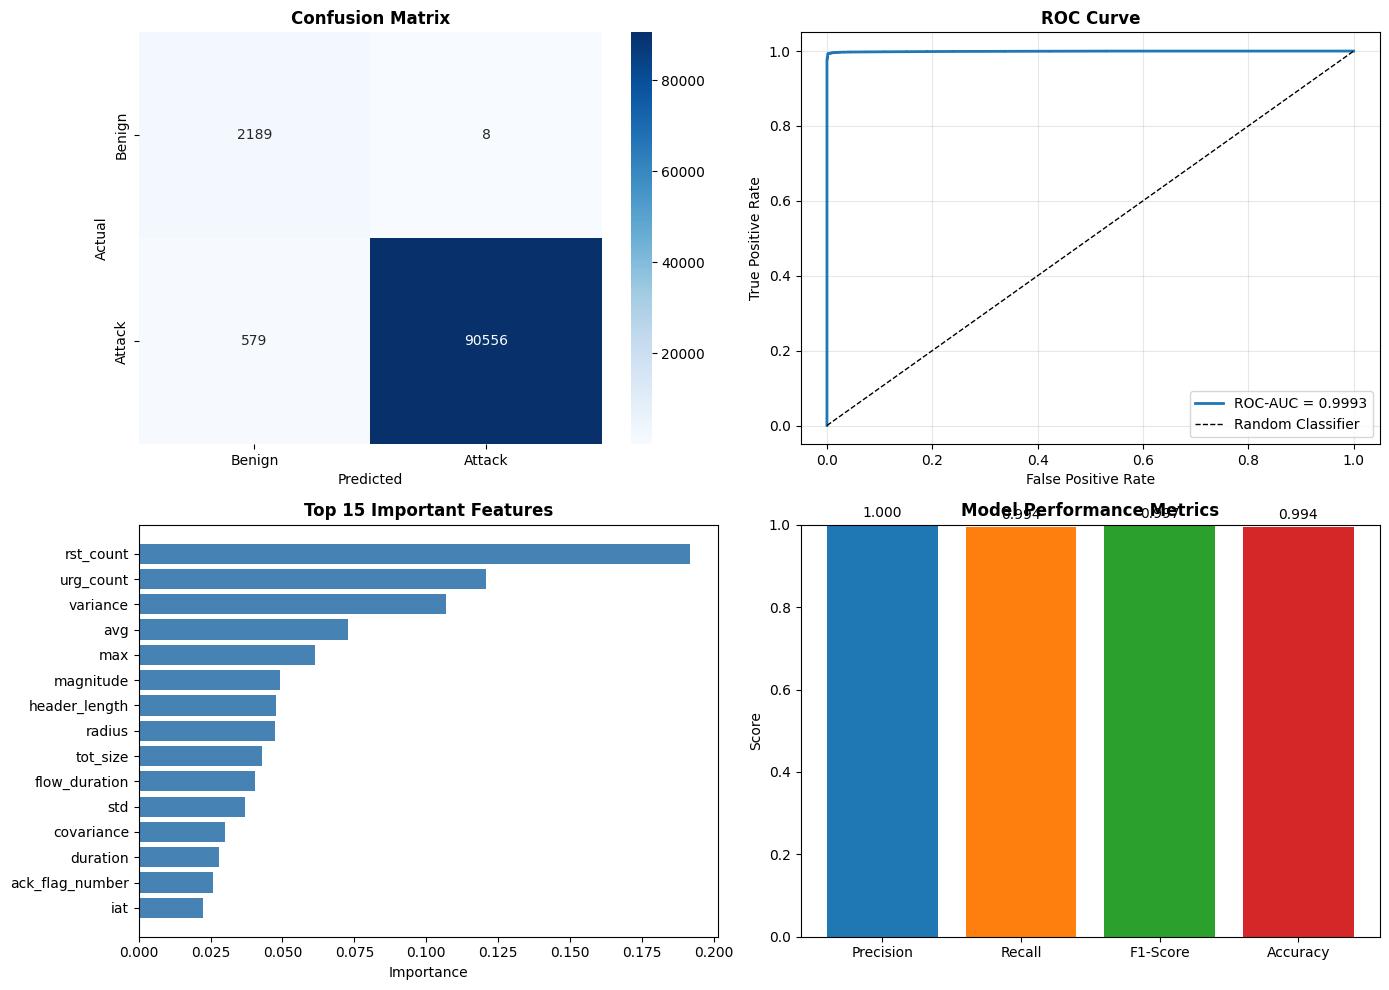

✓ Visualizations completed!


In [10]:
# Step 8: Visualize results

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
axes[0, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0, 1].plot(fpr, tpr, linewidth=2, label=f'ROC-AUC = {roc_auc:.4f}')
axes[0, 1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Feature Importance (Top 15)
feature_importance = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[1, 0].barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
axes[1, 0].set_xlabel('Importance')
axes[1, 0].set_title('Top 15 Important Features', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()

# 4. Precision-Recall Trade-off
metrics_dict = {'Precision': precision, 'Recall': recall, 'F1-Score': f1, 'Accuracy': accuracy}
axes[1, 1].bar(metrics_dict.keys(), metrics_dict.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Model Performance Metrics', fontsize=12, fontweight='bold')
axes[1, 1].set_ylim([0, 1])
for i, (k, v) in enumerate(metrics_dict.items()):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("✓ Visualizations completed!")

In [11]:
# Step 9: Save the model for future use
import joblib

# Save the trained model
model_path = 'models/random_forest_model.pkl'
joblib.dump(rf_model, model_path)
print(f"✓ Model saved to: {model_path}")

# Save the label encoder for protocol_type
encoder_path = 'models/label_encoders.pkl'
joblib.dump(le_dict, encoder_path)
print(f"✓ Label encoders saved to: {encoder_path}")

print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"✓ Model Successfully Trained on {X_train.shape[0]} samples")
print(f"✓ Test Performance:")
print(f"   - Recall: {recall:.4f} (Catching {recall*100:.2f}% of attacks)")
print(f"   - Precision: {precision:.4f} (False alarm rate: {1-precision:.4f})")
print(f"   - ROC-AUC: {roc_auc:.4f}")
print("=" * 60)

✓ Model saved to: models/random_forest_model.pkl
✓ Label encoders saved to: models/label_encoders.pkl

TRAINING SUMMARY
✓ Model Successfully Trained on 373325 samples
✓ Test Performance:
   - Recall: 0.9936 (Catching 99.36% of attacks)
   - Precision: 0.9999 (False alarm rate: 0.0001)
   - ROC-AUC: 0.9993
